This notebook fits by-cell-type models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

In [36]:
#imports

#The path will be managed by conda or whatever on release, but this is fine for now.
import pandas as pd
import numpy as np
import time
import pickle

from formulaic import Formula

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import linregress

from tensorzinb.tensorzinb import TensorZINB

import scMPRAforge as scm


In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")

In [39]:
shendure.set_negative_controls(["minP","noP"])

In [40]:
shendure.ortho_filter()

scMPRAforge: INFO: Dropped 372 of 1833 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [41]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """

    

    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"].to_numpy(),
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except pd.errors.InvalidIndexError:
        return "index_error"

    return zinb_result

def create_matricies(nb_formula,zi_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z
    }

In [43]:
first_time=True

if first_time:
    QC={}
    #loop through all cell-types, produce 
    for cell_type in shendure.data["cell_type"].unique():
        print(cell_type)

        ##subset to current cell-type##
        shendure_subset=shendure.data[shendure.data["cell_type"]==cell_type]


        ## create design matricies ##
        matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cre_id, contr.treatment(base='reference'))",
                            zi_formula="C(rep_id)-1",
                            scmpra=shendure_subset)
        
        ## take the mean for comparison##
        shendure_mean=shendure_subset.groupby("cre_id")["umis_mpra_bc"].agg("mean").sort_values()

        ## fit a model##
        model=tensorzinb_fit(matricies)

        if model=="index_error":
            print("index error")
            continue

        ## compute predictions of mu from the model ##
        linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]
        mu_predictions=np.exp(linear_mu)

        #compute predictions of ZI from the model
        #linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
        #zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

        ## get the names of the CREs ##
        cre_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cre_id, contr.treatment(base='reference')"]
        cre_labeling=cre_labeling.str.removeprefix("T.")
        #cre_labeling=cre_labeling.replace("reference", "negative_control")

        ## label the predictions with CRE names ##
        mu_predictions_df=pd.DataFrame({'cre_id':cre_labeling,'mu':mu_predictions.squeeze()})
        mu_predictions_df.sort_values(by='mu')

        ## merge means & predicted mu into one df for convienient plotting ##
        mu_summary=mu_predictions_df.groupby("cre_id").agg("mean")
        mu_summary = mu_summary.merge(shendure_mean.rename_axis('cre_id').reset_index(), on='cre_id', how='left')
        
        ### Regress & store data for plotting ###
        
        x = mu_summary["umis_mpra_bc"]
        y = mu_summary["mu"]

        

        # Fit regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        #store regression info
        ret={'x':x,
            'y':y,
            'model':model,
            'slope':slope,
            'intercept':intercept,
            'r_value':r_value,
            'p_value':p_value,
            'std_err':std_err
        }
        
        QC[cell_type]=ret
    with open(f"{data_root}/shendure/cache.pkl","wb") as f:
        pickle.dump(QC,f)
else:
    #not first time
    with open(f"{data_root}/shendure/cache.pkl","rb") as f:
        QC=pickle.load(f)

NeuroectodermBrain
EpiblastPrimitiveStreak
SurfaceEctoderm
Mesoderm
Pluripotent
Haematoendothelial
Cardiomyocytes
NeuroectodermRostral
ExEndodermParietal
ExEndodermVisceral


Let's examine the min & max estimates for each cell-type to make sure they are in the right ballpark.

In [ ]:
for cell_type in QC:
    dat=QC[cell_type]["y"]
    print(f"{cell_type} : {min(dat)} to {max(dat)}")

NeuroectodermBrain : 0.0037570508083001647 to 190.78038533602194
EpiblastPrimitiveStreak : 0.01019733621755966 to 448.4822277751438
SurfaceEctoderm : 0.004919295658046585 to 108.59552241052516
Mesoderm : 0.003912700478411217 to 126.30114078518773
Pluripotent : 0.005751184105356012 to 359.0976203559059
Haematoendothelial : 0.0177341070088153 to 260.9417491941028
Cardiomyocytes : 0.024315820899937637 to 182.3869455461282
NeuroectodermRostral : 0.009723366674254972 to 54.38772976842362
ExEndodermParietal : 0.0055395875373600275 to 45.179402621224526
ExEndodermVisceral : 0.008118172185665884 to 207.7190919413428


All in the right ballpark!

Let's examine the correlations between data mean & estimated mu parameters...

In [ ]:
for cell_type in QC:
    print(f"{cell_type} :\t r={QC[cell_type]['r_value']},\t slope={QC[cell_type]['slope']}")

NeuroectodermBrain :	 r=0.9999752293725921,	 slope=1.0489447279034423
EpiblastPrimitiveStreak :	 r=0.9999724440049462,	 slope=1.034431628025371
SurfaceEctoderm :	 r=0.9999643787240314,	 slope=1.0485586662294843
Mesoderm :	 r=0.9999871203177326,	 slope=1.029673949487976
Pluripotent :	 r=0.9999999615295712,	 slope=1.0006691651957607
Haematoendothelial :	 r=0.9998975764211101,	 slope=1.0598448732861083
Cardiomyocytes :	 r=0.9998471052319644,	 slope=1.0684553180493095
NeuroectodermRostral :	 r=0.9999987399119429,	 slope=1.0085893873213925
ExEndodermParietal :	 r=0.9999967763096284,	 slope=1.0057445565437435
ExEndodermVisceral :	 r=0.999986186708872,	 slope=1.0185936393060955


Correlations look very good. Let's check for outliers:

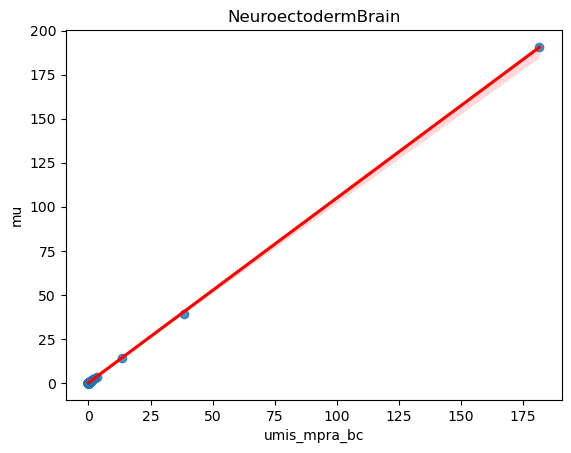

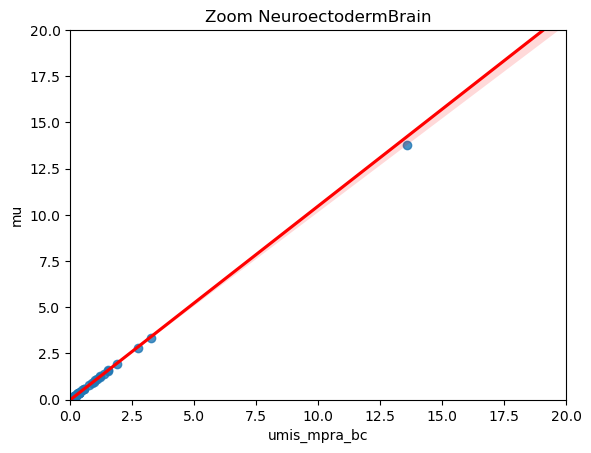

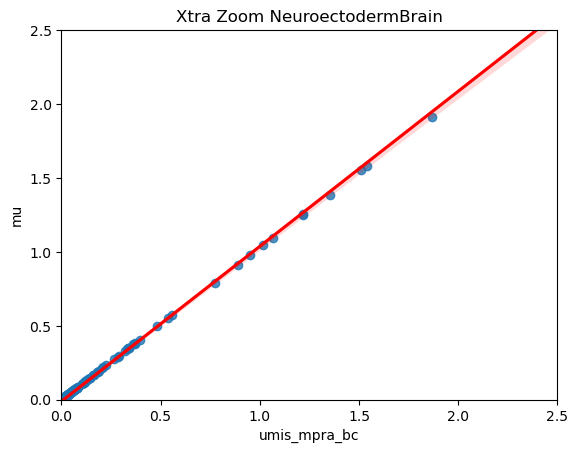

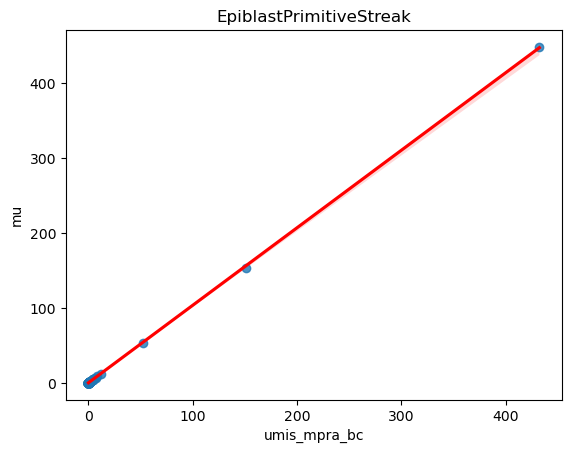

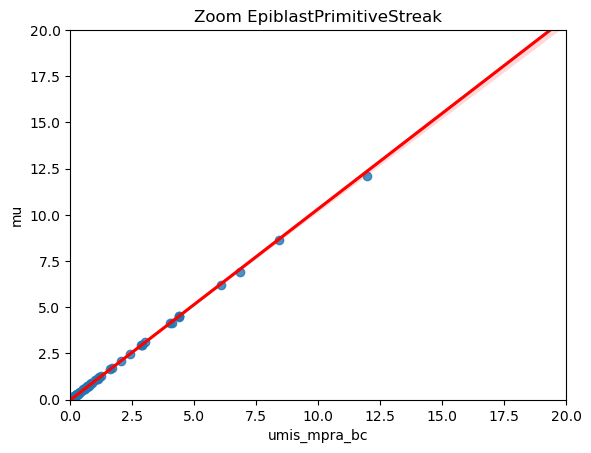

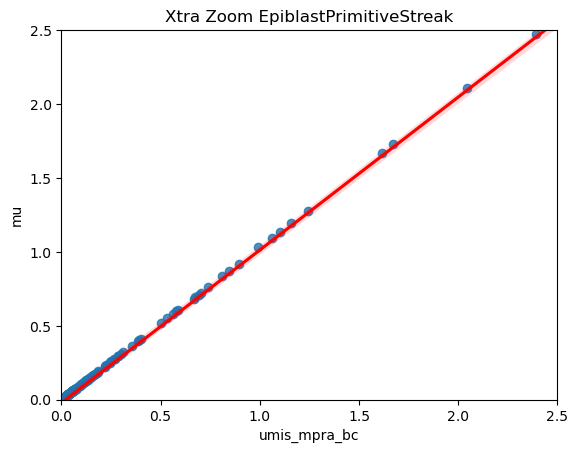

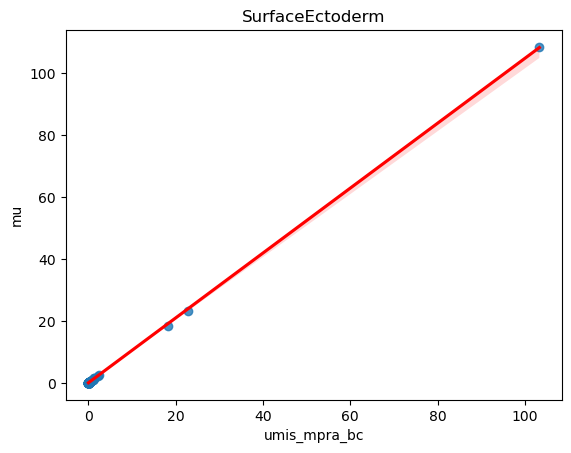

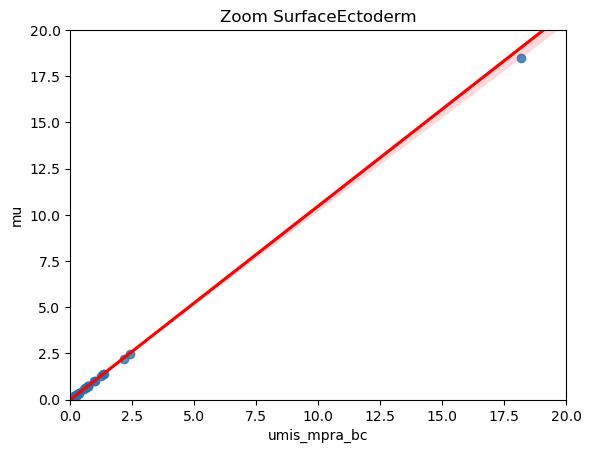

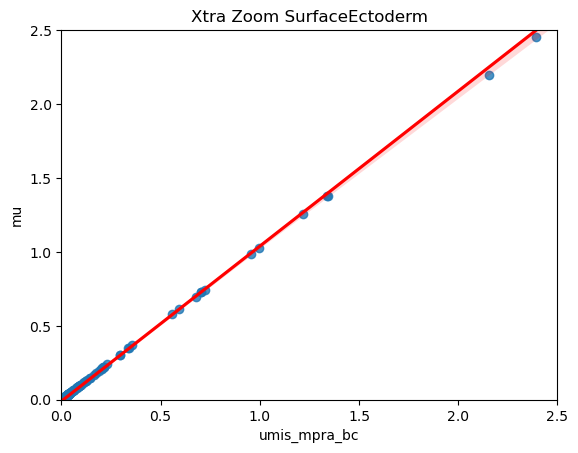

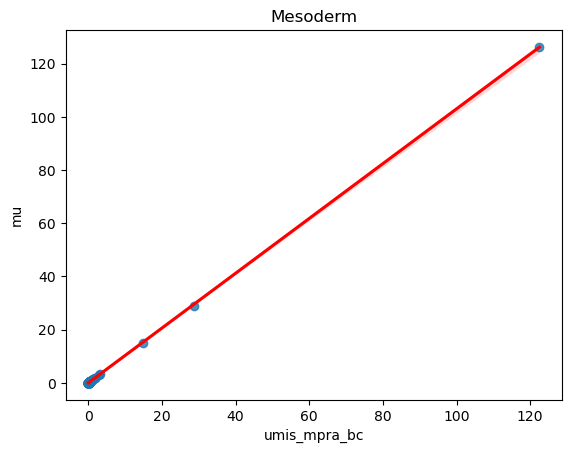

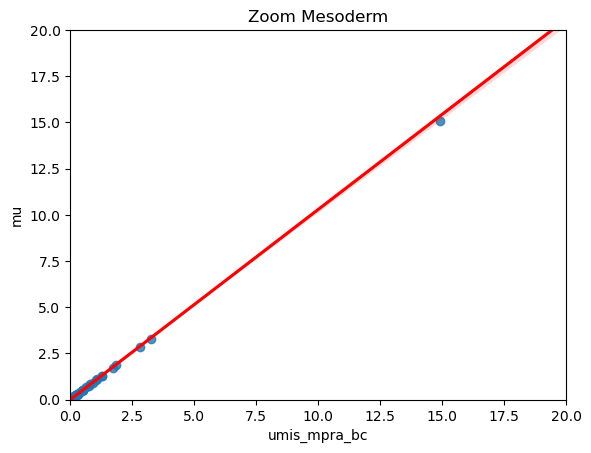

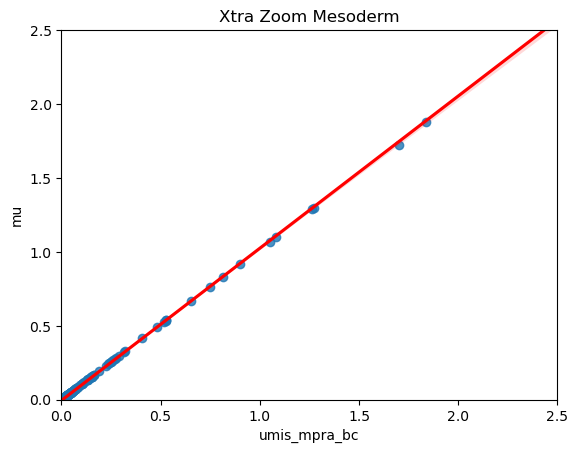

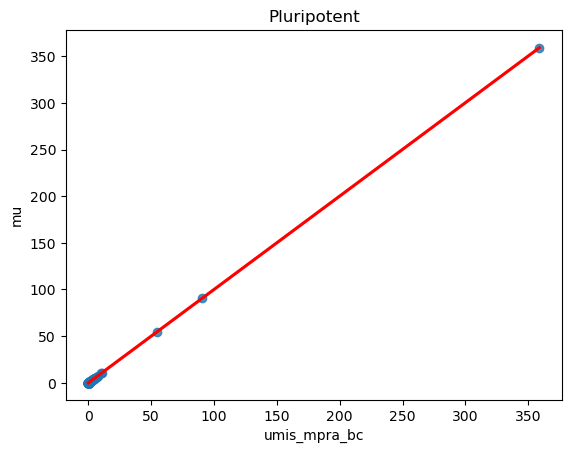

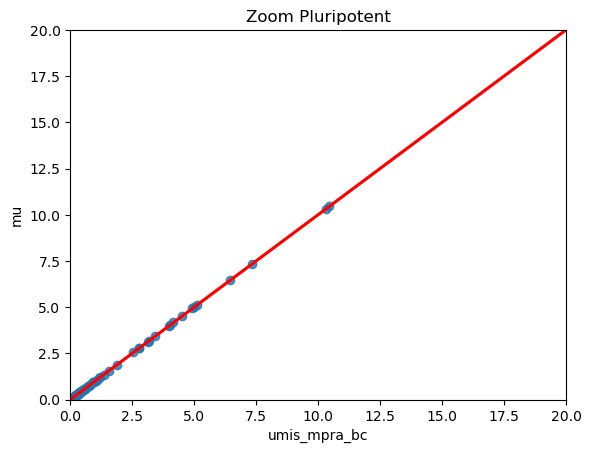

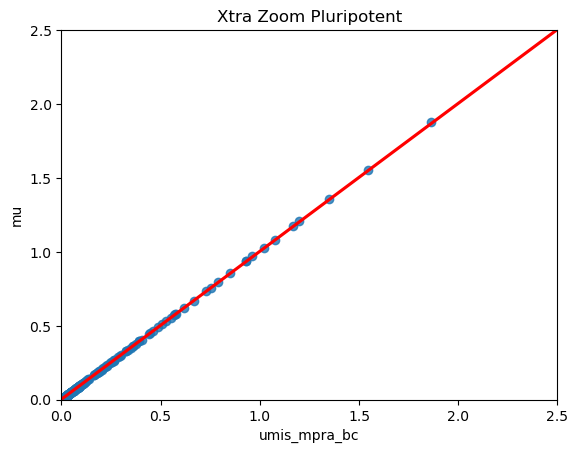

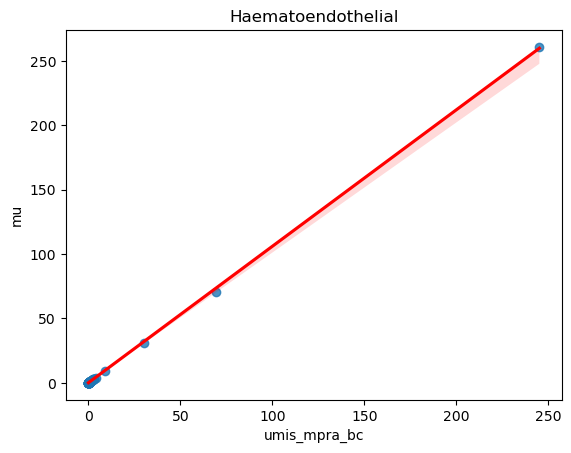

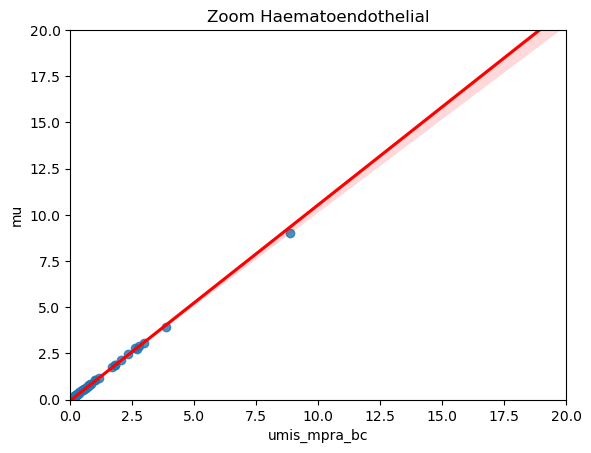

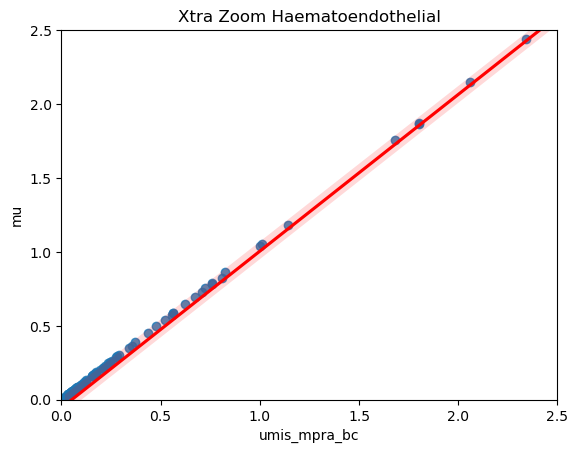

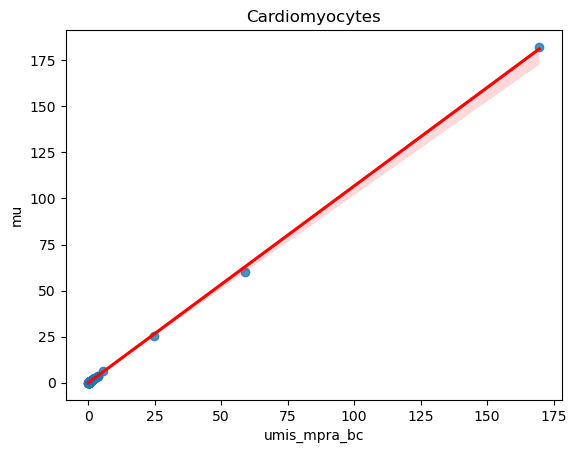

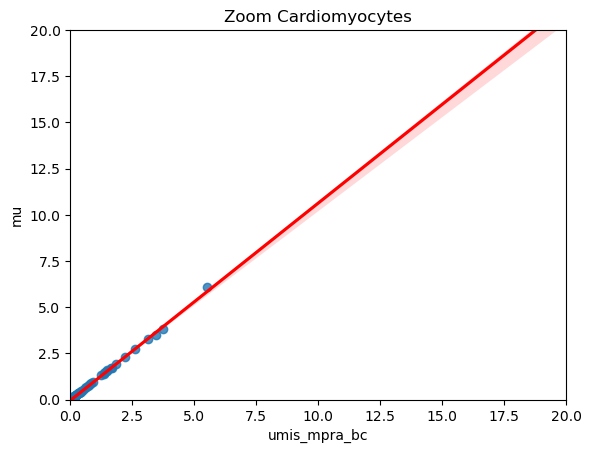

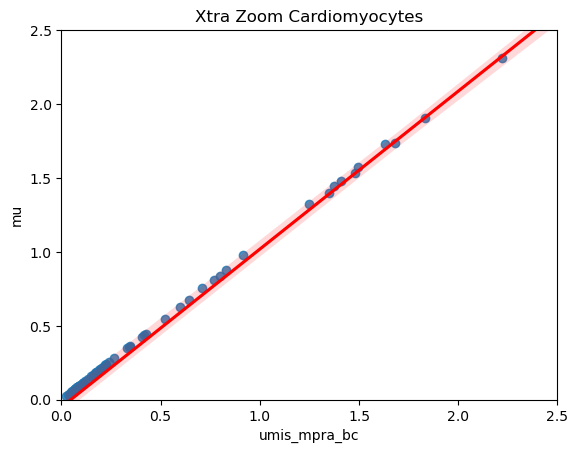

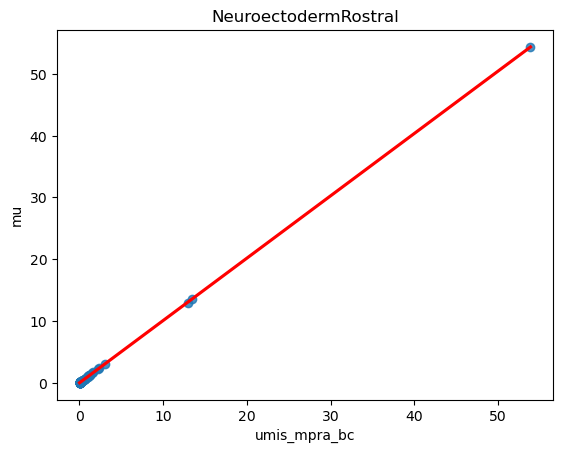

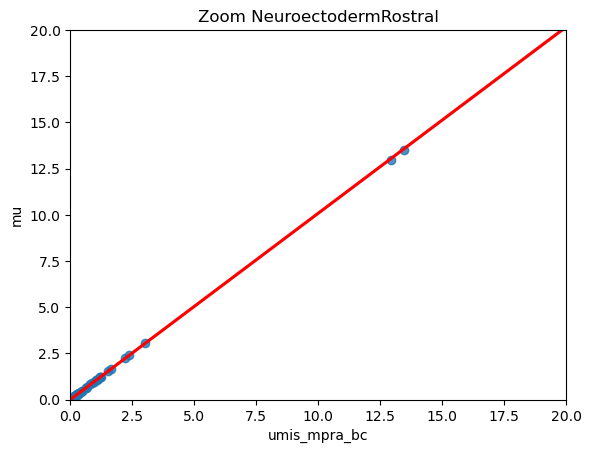

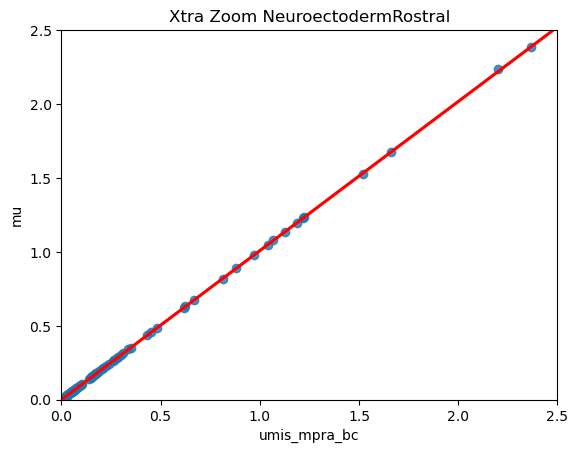

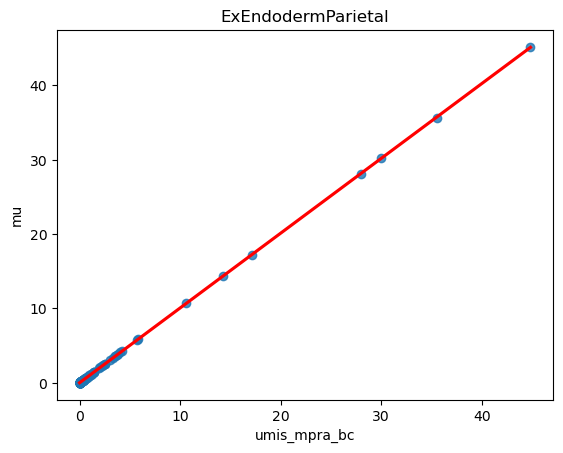

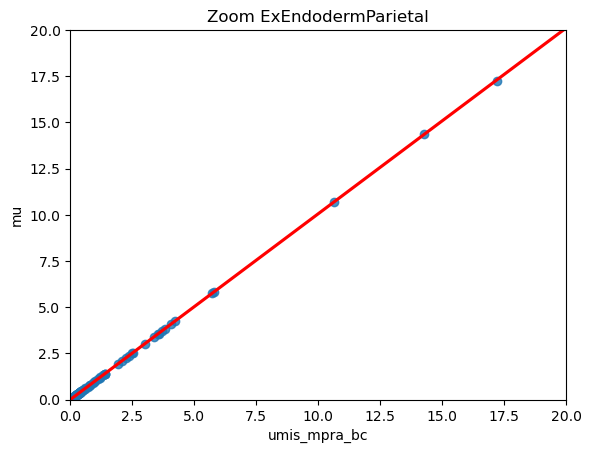

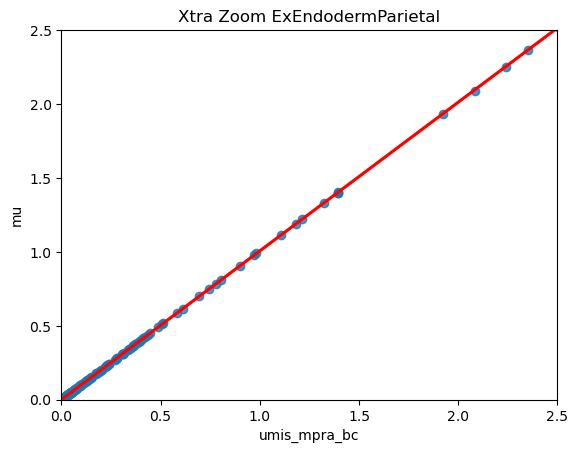

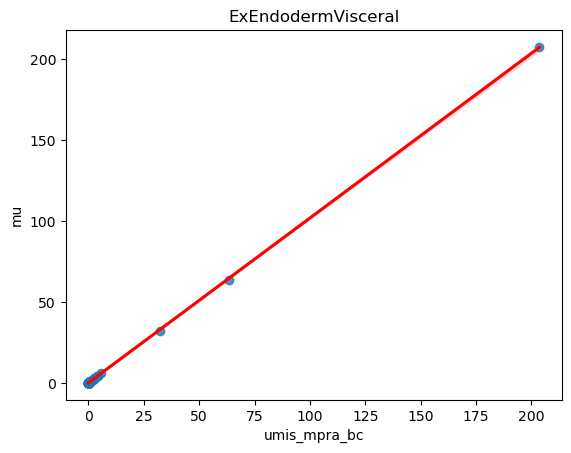

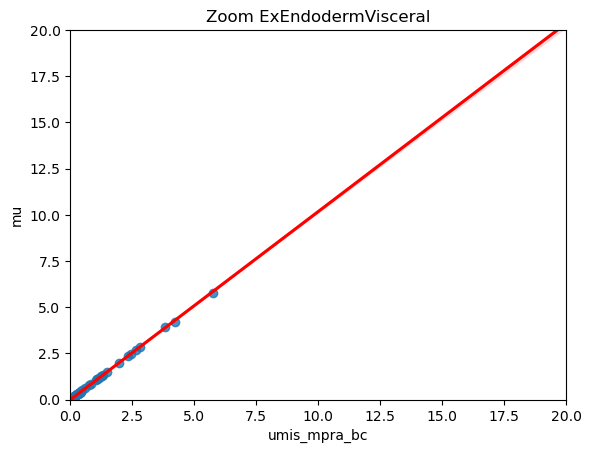

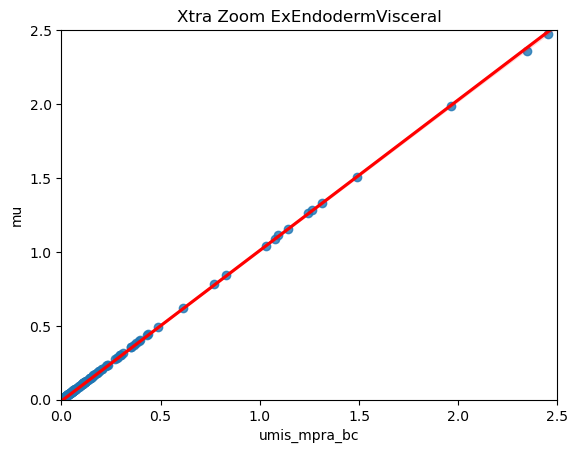

In [ ]:
for cell_type in QC:
    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(cell_type)
    plt.show()

    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(f"Zoom {cell_type}")
    plt.xlim(0, 20)   # Set x-axis limits
    plt.ylim(0, 20)   # Set y-axis limits
    plt.show()

    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(f"Xtra Zoom {cell_type}")
    plt.xlim(0, 2.5)   # Set x-axis limits
    plt.ylim(0, 2.5)   # Set y-axis limits
    plt.show()

    